In [289]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [290]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\Export.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10928 entries, 0 to 10927
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  10928 non-null  str  
 1   Message  10928 non-null  str  
 2   Status   10928 non-null  str  
dtypes: str(3)
memory usage: 256.3 KB


In [291]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [292]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-08-24 19:07:55.490 Last fuel report fs02:  2026-08-24 19:04:40.117


In [293]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     5462 non-null   int64
 1   date      5462 non-null   str  
 2   raw data  5462 non-null   str  
dtypes: int64(1), str(2)
memory usage: 128.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 2221 entries, 0 to 2220
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     2221 non-null   int64
 1   date      2221 non-null   str  
 2   raw data  2221 non-null   str  
dtypes: int64(1), str(2)
memory usage: 52.2 KB


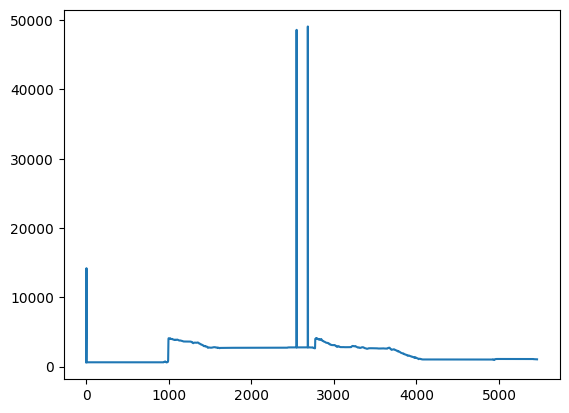

In [294]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

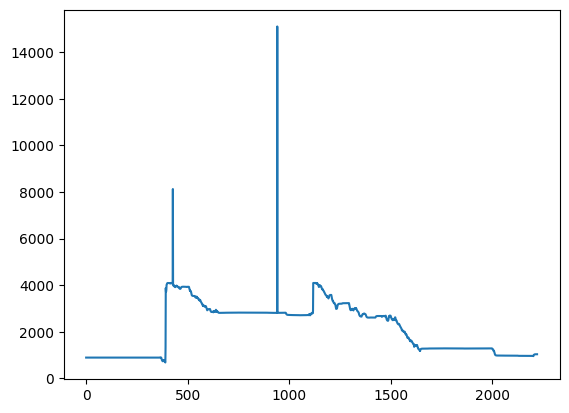

In [295]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [296]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

1 0x25252100230006086948706015659226081417582900013E01421A0210A9BE03015518 -> 260814175829 4098
2 0x25252100230008086948706015659226081417582900013E01600082102301E20015D8 -> 260814175829 4226
3 0x252521002D000A086948706015659226081417582900013E01411A0210A9BE0301552500F2940000010068994A -> 260814175829 4098
4 0x2525210023000C086948706015659226081417582900013E0184A47A37C4D07DC39488 -> 260814175829 14202
2549 0x25252100210E28086948706015659226082019565900013E01071AD8BD0AC2A91F -> 260814175829 48600
2685 0x25252100210EE5086948706015659226082023550000013E0107D5BFBF0EB4A901 -> 260814175829 49087


In [297]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 5462 entries, 0 to 5461
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     5462 non-null   int64
 1   date      5462 non-null   str  
 2   raw data  5462 non-null   str  
dtypes: int64(1), str(2)
memory usage: 170.7 KB


In [298]:
gallons_fs01=[]
gallons_fs02=[]
m1=0.1033
b1=4.2652
m2=0.066
b2=4.7161

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    #print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    #print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
Index: 5462 entries, 0 to 5461
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     5462 non-null   int64
 1   date      5462 non-null   str  
 2   raw data  5462 non-null   str  
dtypes: int64(1), str(2)
memory usage: 170.7 KB


In [299]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260821124025
date2=260821134755

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>=(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<=(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>=(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<=(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
raising 71.35276160164337 70.91613805842006 0.43662354322330543
raising 80.49456703788121 71.35276160164337 9.578428979461151
raising 104.45428397225983 80.49456703788121 33.53814591383977
raising 108.0291392324006 104.45428397225983 37.113001173980535
raising 108.4657627756239 108.0291392324006 37.54962471720384
droping 108.2747399754637 108.4657627756239 37.35860191704364
raising 108.57491866142972 108.2747399754637 37.65878060300966
raising 108.9569642617501 108.57491866142972 38.04082620333004
raising 109.25714294771613 108.9569642617501 38.34100488929607
raising 109.33900986207051 109.25714294771613 38.42287180365045
raising 109.5300326622307 109.33900986207051 38.613894603810635
raising 109.966656205454 109.5300326622307 39.05051814703394
droping 109.5846106051336 109.966656205454 38.668472546713545
raising 109.74834443384233 109.5846106051336 38.832206375422274
raising 110.40327974867729 109.7483